Title: Multi-Class Breast Cancer Subtype Classification


In [1]:
# Cloning the data
!git clone https://git.wur.nl/bioinformatics/fte35306

Cloning into 'fte35306'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 23 (delta 5), reused 15 (delta 5), pack-reused 8 (from 1)
Receiving objects: 100% (23/23), 396.30 MiB | 8.25 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

In [3]:
# Loading the classification dataset into variable data
data = pd.read_csv("fte35306/data_5_classes_public.csv.gz")

In [4]:
# Preview of first 5 rows to check the data structure
data.head()


,sample_id,RERE,RNF165,PHF7,CIDEA,TENT2,SLC17A3,SDS,ATP6V1C2,F3,...,VN1R4,TRPV5,UGGT1,CR590356,VPS72,CSMD3,CC2D1A,IGSF9,FAM71A,label
0,MB-6145,9.379186,7.977053,6.190797,7.197867,7.655081,5.581064,6.652062,5.385198,6.030982,...,5.532594,5.478770,8.090134,7.383369,7.654590,5.294739,6.784536,6.799956,5.266810,3
1,MB-5206,9.256807,6.601926,6.286018,6.366614,8.243848,5.517185,5.908519,5.374320,6.399823,...,5.884942,5.513096,7.508961,5.771645,8.037253,5.387848,6.184186,6.496334,5.117170,3
2,MB-3850,8.737099,5.931422,5.997456,6.407027,8.370692,5.296163,6.264230,5.357061,6.829624,...,5.399208,5.369684,7.328341,5.833027,7.854866,5.493994,6.161049,6.800394,5.273664,3
3,MB-0487,9.549530,6.402682,5.727074,10.731211,8.231355,5.725315,5.829583,5.563861,6.869321,...,5.420856,5.248512,7.796720,5.971765,7.985320,5.297923,5.981484,6.686198,5.832585,0
4,MB-5211,9.187409,5.458691,5.776863,5.692987,8.718383,5.671150,7.490033,5.305555,5.344479,...,5.466153,5.376499,7.344714,6.182388,7.685947,5.473454,6.453766,6.097018,4.904562,0


In [5]:
# Dataset dimension check-number of samples and features
data.shape



(1763, 20605)

In [6]:
# Statistical summaryof the dataset
data.describe()

,RERE,RNF165,PHF7,CIDEA,TENT2,SLC17A3,SDS,ATP6V1C2,F3,FAM71C,...,VN1R4,TRPV5,UGGT1,CR590356,VPS72,CSMD3,CC2D1A,IGSF9,FAM71A,label
count,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,...,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1763.000000,1762.000000,1763.000000
mean,9.040678,6.421547,5.947580,6.402258,8.252519,5.593420,6.440283,5.624981,5.964613,5.416329,...,5.431295,5.475038,7.623895,6.229026,8.206513,5.370494,6.350815,7.028736,5.310188,0.507657
std,0.504343,0.749798,0.324294,1.107016,0.437566,0.141934,0.528975,0.532877,0.494752,0.114973,...,0.138330,0.153755,0.511933,0.444640,0.413632,0.390215,0.286012,0.698678,0.229760,1.086144
min,7.300890,5.128143,5.233895,4.824325,5.855153,5.168285,5.238349,4.967659,5.121756,5.050416,...,4.808093,4.785058,6.271389,5.285343,7.184368,4.843562,5.634848,5.155719,4.667968,0.000000
25%,8.676997,5.864089,5.724341,5.572794,7.998856,5.506453,6.059812,5.334457,5.629632,5.343283,...,5.339050,5.375337,7.298747,5.915537,7.924778,5.213776,6.150842,6.537372,5.174106,0.000000
50%,9.060159,6.263294,5.902010,6.015611,8.290234,5.585445,6.381787,5.456229,5.854052,5.416076,...,5.428832,5.466477,7.585633,6.134426,8.162410,5.305420,6.325456,6.994028,5.305168,0.000000
75%,9.386876,6.817923,6.120737,6.973234,8.537740,5.672699,6.764597,5.677050,6.178026,5.488334,...,5.520799,5.558998,7.862476,6.448613,8.454095,5.412094,6.499392,7.489866,5.446192,0.000000
max,10.506879,10.067075,7.568060,11.958567,9.793278,7.600751,9.597302,10.383044,9.204628,5.852262,...,6.017726,6.233854,10.068962,8.557961,11.093532,10.897661,8.214535,10.024777,6.628415,4.000000


In [7]:
# Seperaturing the targeted labels and features
# Spliting the dataset to a ratio of 70/30 int training and validation set, stratified to preserve class ratio
X = data.drop(['sample_id', 'label'], axis=1)
y = data['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, stratify = y, random_state =4)


Feature variance stats (before scaling):
Mean variance:   0.2346
Median variance: 0.1288
Min variance:    0.0118
Max variance:    9.2279


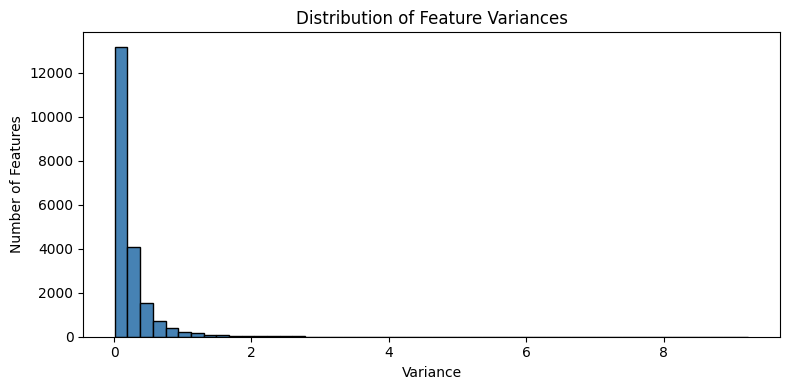

In [8]:
# Checking for variance on training dataset, pre-scaling check
# Highly skewed dataset suggest scaling is important

print("\nFeature variance stats (before scaling):")
variances = X_train.var()
print(f"Mean variance:   {variances.mean():.4f}")
print(f"Median variance: {variances.median():.4f}")
print(f"Min variance:    {variances.min():.4f}")
print(f"Max variance:    {variances.max():.4f}")

# Variance Distribution plot: Number features vs variance
plt.figure(figsize=(8, 4))
plt.hist(variances, bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Feature Variances')
plt.xlabel('Variance')
plt.ylabel('Number of Features')
plt.tight_layout()
plt.show()

Class distribution in training set:
label
0    968
1     92
2     15
3    133
4     26
Name: count, dtype: int64

Class distribution in val set:
label
0    415
1     39
2      6
3     57
4     12
Name: count, dtype: int64


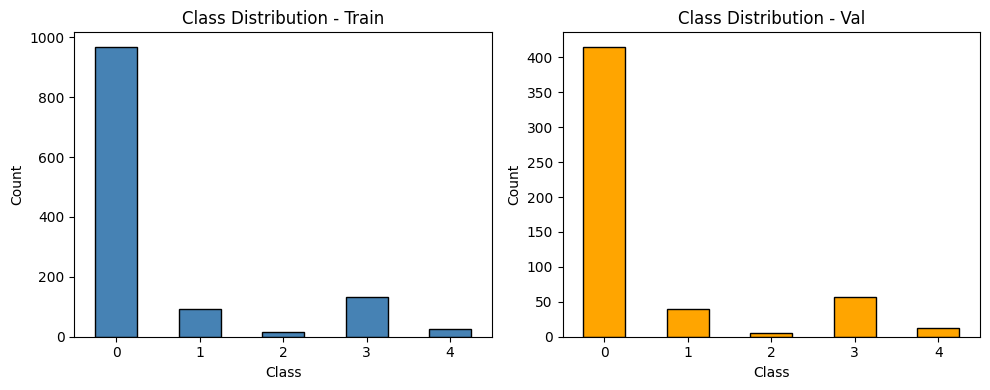

In [9]:
# Check for class imbalance in training and validation set
print("Class distribution in training set:")
print(y_train.value_counts().sort_index())
print("\nClass distribution in val set:")
print(y_val.value_counts().sort_index())

# Class distribution for training and valida
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
y_train.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution - Train')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
y_val.value_counts().sort_index().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Class Distribution - Val')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# Imputing  missing values through  calculating mean.
# Fitting on trainng set preventing data leakage into validation

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

# Standardising features to zero mean and unit variance
# Fit on trained data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

In [11]:
"""
Dimensionality REduction using PCA
Only training data is fitted to avoid data leakage into validation set
Cumulative variance calculation: total information captured by components

**************
Parameters
**************
X_train_scaled : array like of shape (n_samples, n_features)
    Training data(Scaled)
X_val_scaled : array like of shape (n_samples, n_features)
    Validation data(scaled)
n_components: int, default =50, 300
 different values for n_components were tested
 Number of PCA components retained
**************
Returns
**************
X_train_pca : array like of shape (n_train_samples, n_components)
    Training data after dimensionality reduction

X_val_pca : array like of shape (n_val_samples, n_components)
    Validation data after dimensionality reduction
pca: fitted PCA object for later use on the test data

"""
def dimensional_reduction(X_train_scaled, X_val_scaled, n_components=300):
    # First fit PCA with all components to plot elbow
    pca_full = PCA()
    pca_full.fit(X_train_scaled)

    # Calculate cumulative variance
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

    # Elbow plot
    plt.figure(figsize=(10, 5))

    # Plot 1 - individual variance
    plt.subplot(1, 2, 1)
    plt.plot(pca_full.explained_variance_ratio_, 'bo-', markersize=4)
    plt.xlabel('Number of Components')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Individual Explained Variance')
    plt.axvline(x=n_components, color='red', linestyle='--', label=f'n={n_components}')
    plt.legend()

    # Plot 2 - cumulative variance
    plt.subplot(1, 2, 2)
    plt.plot(cumulative_variance, 'bo-', markersize=4)
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance')
    plt.axhline(y=0.95, color='green', linestyle='--', label='95% variance')
    plt.axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
    plt.axvline(x=n_components, color='red', linestyle='--', label=f'n={n_components}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    n_90 = np.argmax(cumulative_variance >= 0.90) + 1
    n_95 = np.argmax(cumulative_variance >= 0.95) + 1
    print(f'Components needed for 90% variance: {n_90}')
    print(f'Components needed for 95% variance: {n_95}')

    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)

    print(f'Variance explained with {n_components} components: {sum(pca.explained_variance_ratio_):.3f}')
    print(f'X_train_pca shape: {X_train_pca.shape}')
    print(f'X_val_pca shape: {X_val_pca.shape}')

    return X_train_pca, X_val_pca, pca

In [13]:
def run_without_preprocessing(X_train_scaled, X_val_scaled, y_train, y_val):
    """
Train and evaluates baseline models on scaled data without PCA or GridSearch.

Uses fixed hyperparameters with class_weight='balanced' to handle class imbalance.
Reports classification report and balncedd accuracy for each model.

**************
Parameters
**************
X_train_scaled : array like of shape (n_samples, n_features)
    Training data(Scaled)
X_val_scaled : array like of shape (n_samples, n_features)
    Validation data(scaled)
y_train : array like of shape (n_samples,)
    Training labels
y_val : array like of shape (n_samples,)
    Validation labels

**************
Returns
**************
results : dictionary
    Dictionary containing balanced accuracy scores for each model.
    models : dictionary
    Dictionary containing fitted models.
    """
    models = {
        'LR':  LogisticRegression(max_iter=5000, class_weight='balanced'),
        'QDA': QuadraticDiscriminantAnalysis(reg_param=0.5),
        'SVM': SVC(kernel='rbf', class_weight='balanced'),
        'RF':  RandomForestClassifier(
                    n_estimators=500,
                    class_weight='balanced_subsample',
                    min_samples_leaf=2,
                    random_state=42
               )
    }

    results = {}

    print(f'\n{"="*50}')
    print('WITHOUT PREPROCESSING (no PCA, no GridSearch)')
    print(f'{"="*50}')

    for model_name, model in models.items():
        print(f'\n--- {model_name} ---')
        try:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_val_scaled)

            score = balanced_accuracy_score(y_val, y_pred)
            results[model_name] = score

            print(classification_report(
                y_val, y_pred,
                target_names=['Class0','Class1','Class2','Class3','Class4'],
                zero_division=0
            ))
            print(f'Balanced Accuracy: {score:.3f}')

        except Exception as e:
            print(f'{model_name} failed: {e}')
            results[model_name] = 0.0

    return results, models

In [ ]:
def running_with_preprocessing(X_train_pca, X_val_pca, y_train, y_val):
    """
Train and evalating models on PCA-reduced data with GridSearchCV tuning.

Utilizese stratifiedKfold with 5 splits for cross-validation.
Reports classification report and balncedd accuracy for each model.
class_weights are balanced to handle class imbalance preventing models from ignoring minority classes
**************
Parameters
**************
X_train_pca: array like of shape (n_train_samples, n_components)
    Training data after dimensionality reduction
X_val_pca: array like of shape (n_val_samples, n_components)
    Validation data after dimensionality reduction
    y_train : array like of shape (n_samples,)
    Training labels
y_val : array like of shape (n_samples,)
    Validation labels

MODELS:
# Logistic Regression: Searches over regularization parameter C.
# Quadratic Discriminant Analysis: Searches over regularization parameter reg_param.
    reg_param added to stabilise covariance matrix estimation
#Support vector machine with RBF kernel: Searches over regularization parameter C, gamma
# Random Forest: Searches over number of estimators, maximum depth, minimum samples per leaf.
    balanced_subsample reweights classes within each boostrap sample.

**************
Returns
**************
results : dictionary {model_name:balanced_accuracy_score}
    Dictionary containing balanced accuracy scores for each model.

best_models : dictionary {model_name: {grid, score, params}}
    Dictionary containing fitted models and their best parameters

    """

    stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models_parameters = {
        'LR': {
            'model': LogisticRegression(max_iter=5000),
            'params': {'C': [0.01, 0.1, 10],
                       'class_weight': ['balanced']}
        },
        'QDA': {
            'model': QuadraticDiscriminantAnalysis(),
            'params': {'reg_param': [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]}
        },
        'SVM': {
            'model': SVC(kernel='rbf'),
            'params': {'C': [0.1, 1, 10],
                       'gamma': [0.01, 0.1, 1],
                       'class_weight': ['balanced']}
        },
        'RF': {
            'model': RandomForestClassifier(random_state=42),
            'params': {'n_estimators': [100, 300, 500],
                       'max_depth': [None, 10, 20, 30],
                       'min_samples_leaf': [1, 2, 4],
                       'class_weight': ['balanced', 'balanced_subsample']}
        }
    }

    results = {}
    best_models = {}

    print(f'\n{"="*50}')
    print('WITH PREPROCESSING (PCA, GridSearch)')
    print(f'{"="*50}')

    for model_name, mp in models_parameters.items():
        print(f'\n--- {model_name} ---')
        try:
            grid = GridSearchCV(mp['model'], mp['params'], cv=stratified_cv, scoring='f1_macro', n_jobs=-1)
            grid.fit(X_train_pca, y_train)

            best_models[model_name] = {
                'grid': grid,
                'score': grid.best_score_,
                'params': grid.best_params_
            }

            y_pred = grid.predict(X_val_pca)
            score = balanced_accuracy_score(y_val, y_pred)
            results[model_name] = score

            print(f'Best_parameters: {grid.best_params_}')
            print(f'Best_CV_score: {grid.best_score_:.4f}')
            print(classification_report(y_val, y_pred, target_names=['Class0','Class1','Class2','Class3','Class4'], zero_division=0))
            print(f' VAL_Accuracy: {score:.3f}')

        except Exception as e:
            print(f'{model_name} failed: {e}')
            results[model_name] = 0

    return results, best_models

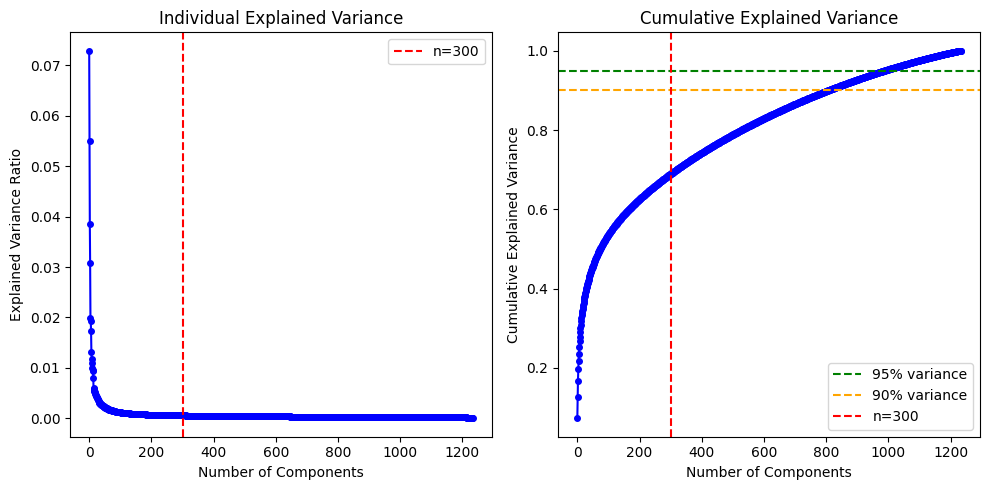

Components needed for 90% variance: 808
Components needed for 95% variance: 990
Variance explained with 300 components: 0.684
X_train_pca shape: (1234, 300)
X_val_pca shape: (529, 300)

WITHOUT PREPROCESSING (no PCA, no GridSearch)

--- LR ---
              precision    recall  f1-score   support

      Class0       0.82      0.96      0.88       415
      Class1       0.55      0.28      0.37        39
      Class2       1.00      0.17      0.29         6
      Class3       0.14      0.05      0.08        57
      Class4       0.00      0.00      0.00        12

    accuracy                           0.78       529
   macro avg       0.50      0.29      0.32       529
weighted avg       0.71      0.78      0.73       529

Balanced Accuracy: 0.292

--- QDA ---


/home/pratibha/.local/lib/python3.10/site-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


              precision    recall  f1-score   support

      Class0       0.00      0.00      0.00       415
      Class1       0.00      0.00      0.00        39
      Class2       0.01      1.00      0.02         6
      Class3       0.00      0.00      0.00        57
      Class4       0.00      0.00      0.00        12

    accuracy                           0.01       529
   macro avg       0.00      0.20      0.00       529
weighted avg       0.00      0.01      0.00       529

Balanced Accuracy: 0.200

--- SVM ---
              precision    recall  f1-score   support

      Class0       0.84      0.82      0.83       415
      Class1       0.40      0.31      0.35        39
      Class2       0.00      0.00      0.00         6
      Class3       0.17      0.28      0.21        57
      Class4       0.00      0.00      0.00        12

    accuracy                           0.70       529
   macro avg       0.28      0.28      0.28       529
weighted avg       0.71      0.70      

NameError: name 'running_with_preprocessing' is not defined

In [15]:
"""
# Dimensionality Reduction using PCA for 300 components
  Only training data is fitted to avoid data leakage into validation sets
# Training and evaluate all models on scaled data without PCA or GridSearch.
# Training and evalating models on PCA-reduced data with GridSearchCV tuning.
"""
X_train_pca, X_val_pca, pca = dimensional_reduction(
    X_train_scaled, X_val_scaled, n_components=300)

results_without, fitted_models_without = run_without_preprocessing(
    X_train_scaled, X_val_scaled, y_train, y_val)

results_with, best_models = running_with_preprocessing(
    X_train_pca, X_val_pca, y_train, y_val)

In [ ]:
# Compare balance accuracy across all models in both pipeline settong
# Orange = with preprocessing
# Blue = without preprocessing
# Higher bar = better generalisation on valaidation set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_without.keys(), results_without.values(), color='steelblue', edgecolor='black')
axes[0].set_title('Without Preprocessing')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_ylim(0, 1)
for i, (k, v) in enumerate(results_without.items()):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(results_with.keys(), results_with.values(), color='orange', edgecolor='black')
axes[1].set_title('With Preprocessing (PCA + GridSearch)')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_ylim(0, 1)
for i, (k, v) in enumerate(results_with.items()):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
"""
Plot confusion matrix for each model using seaborn library

*************
Parameters
*************
y_val : array like of shape (n_samples,)
    Validation labels
y_pred : array like of shape (n_samples,)
    Predicted labels
model_name : str
    Name of the model

"""

from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y_val, y_pred, model_name):
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class0','Class1','Class2','Class3','Class4'],
                yticklabels=['Class0','Class1','Class2','Class3','Class4'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

for model_name, model in fitted_models_without.items():
    y_pred = model.predict(X_val_scaled)
    plot_confusion_matrix(y_val, y_pred, f'{model_name} - Without Preprocessing')

for model_name, res in best_models.items():
    y_pred = res['grid'].predict(X_val_pca)
    plot_confusion_matrix(y_val, y_pred, f'{model_name} - With Preprocessing')

In [ ]:
"""
Checks overfitting by comparing macro F1 score on train and validation sets.
Fits each model on training data and evaluates on both train and validation sets.
Plots a grouped bar chart of train vs validation scores for each model.
Prints the gap between train and validation score — larger gap means more overfitting.
"""

def check_overfitting(models, X_train_scaled, X_val_scaled, y_train, y_val):

    #Intialising dictionaries to store training and validation sets
    train_scores = {}
    val_scores = {}

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)

        #Computation of macro F1 score on training set
        y_train_pred = model.predict(X_train_scaled)
        train_scores[model_name] = f1_score(y_train, y_train_pred, average='macro')

        #Computing maccro F1 on validation set
        y_val_pred = model.predict(X_val_scaled)
        val_scores[model_name] = f1_score(y_val, y_val_pred, average='macro')


    x = np.arange(len(train_scores))
    width = 0.35
    #Plotting training vs validation scores side by side for each model
    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, train_scores.values(), width, label='Train', color='steelblue')
    plt.bar(x + width/2, val_scores.values(), width, label='Val', color='orange')
    plt.xticks(x, train_scores.keys())
    plt.ylabel('Macro F1 Score')
    plt.title('Train vs Val Score — Overfitting Check')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nTrain vs Val gap (larger = more overfitting):")
    for model_name in train_scores:
        gap = train_scores[model_name] - val_scores[model_name]
        print(f"{model_name}: train={train_scores[model_name]:.3f}, val={val_scores[model_name]:.3f}, gap={gap:.3f}")

# Running overfitting check on baseline model trained without preprocessing
check_overfitting(fitted_models_without, X_train_scaled, X_val_scaled, y_train, y_val)

In [ ]:
# Applying same preprocessing pipeline to test
# Use imputer and scaler fitted on training data only
# seelct best model based on validation balanced accuracy
# Generate submission file with sample_id and predicated label


df_test = pd.read_csv("fte35306/data_5_classes_test.csv.gz")
X_test = df_test.drop(['sample_id'], axis=1)

X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)
X_test_pca = pca.transform(X_test_scaled)

best_model = max(results_with, key=results_with.get)
y_pred = best_models[best_model]['grid'].predict(X_test_pca)

sample_ids = df_test["sample_id"].to_numpy()
submission_df = pd.DataFrame({"sample_id": sample_ids, "label": y_pred})
submission_df.to_csv("submission.csv", index=False)
submission_df.head()

from google.colab import files
files.download('submission.csv')